# Comprehensive Data Preprocessing & Feature Engineering
The purpose of this notebook is to transform the raw TMDB 5000 dataset into a clean, professional format for the dashboard. 
Key steps include:
1. **Handling Missing Values:** Imputing missing data instead of simple deletion.
2. **Advanced Feature Engineering:** Creating profitability metrics and grouping languages.
3. **Outlier Detection & Treatment:** Using the Interquartile Range (IQR) method.
4. **Log Transformation:** Handling skewed revenue and budget figures for better visualization.

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the raw dataset
# Ensure 'raw_movies.csv' is placed in the 'data/' folder
df = pd.read_csv('../data/raw_movies.csv')
print(f"Initial Dataset Shape: {df.shape}")

Initial Dataset Shape: (4803, 20)


## 1. Missing Values & Basic Cleaning
Instead of dropping all rows with missing values, we will:
- Fill `runtime` missing values with the **Median**.
- Fill `vote_average` missing values with the **Mean**.
- Drop rows only if the `release_date` or `title` is missing.
- Ensure all movies have a `runtime` greater than 0.

In [2]:
# --- STEP 1: CRITICAL DATE HANDLING ---
# Convert to datetime and extract year first so we don't lose it
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# --- STEP 2: MISSING VALUES IMPUTATION ---
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['vote_average'] = df['vote_average'].fillna(df['vote_average'].mean())

# Drop rows only if critical info (Title or Year) is missing
df.dropna(subset=['release_year', 'title'], inplace=True)

# Basic filtering: Keep movies with a valid runtime
df = df[df['runtime'] > 0]

# Remove any duplicates
df.drop_duplicates(inplace=True)

## 2. Feature Engineering
We will decompile the JSON `genres` column to extract the **Main Genre** and calculate financial metrics:
- **Profit:** (Revenue - Budget).
- **Language Grouping:** Group less frequent languages into an 'Other' category to simplify dashboard filters.

In [3]:
# Function to parse JSON and extract the first genre name
def get_main_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0]['name'] if len(genres) > 0 else 'Unknown'
    except:
        return 'Unknown'

df['main_genre'] = df['genres'].apply(get_main_genre)

# Financial Features
df['release_year'] = pd.to_datetime(df['release_date']).dt.year
df['profit'] = df['revenue'] - df['budget']

# Language Grouping: Keep Top 5 languages and group the rest
top_lang = df['original_language'].value_counts().nlargest(5).index
df['language_group'] = df['original_language'].apply(lambda x: x if x in top_lang else 'Other')

## 3. Outlier Handling (IQR Method)
Financial data in the movie industry is highly skewed due to blockbusters. We will use the **IQR (Interquartile Range)** method to identify and manage outliers to ensure our visualizations are readable.

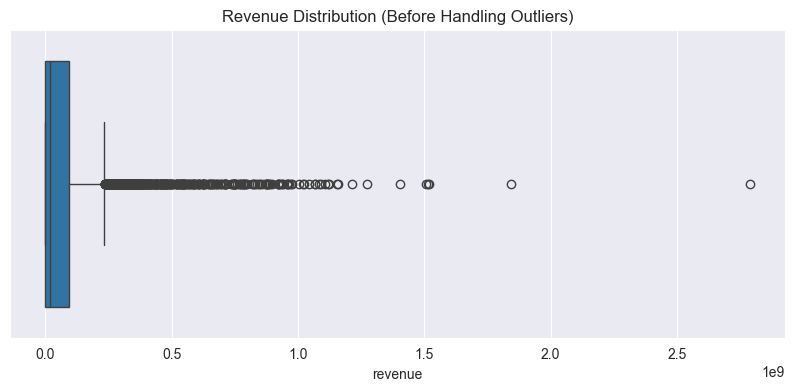

Shape after IQR treatment: (4071, 24)


In [4]:
# Visualization of Outliers before handling
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['revenue'])
plt.title('Revenue Distribution (Before Handling Outliers)')
plt.show()

# IQR Function to filter outliers
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# Applying IQR on Budget and Revenue
df_no_outliers = remove_outliers_iqr(df, 'revenue')
df_no_outliers = remove_outliers_iqr(df_no_outliers, 'budget')

print(f"Shape after IQR treatment: {df_no_outliers.shape}")

## 4. Log Transformation & Saving
To handle the remaining variance and make the distributions more normalized for charts like Histograms, we apply a **Log Transformation** (`log1p`). 
Finally, we save the processed data.

In [5]:
# Applying Log Transformation to handle skewed numerical values
# We use log1p (log(1+x)) to safely handle zero values
df_no_outliers['log_revenue'] = np.log1p(df_no_outliers['revenue'])
df_no_outliers['log_budget'] = np.log1p(df_no_outliers['budget'])

# Select essential columns for the dashboard
final_cols = ['title', 'budget', 'revenue', 'profit', 'log_budget', 'log_revenue', 
              'release_year', 'main_genre', 'runtime', 'vote_average', 'language_group', 'popularity']

df_final = df_no_outliers[final_cols]

# Save to cleaned CSV
df_final.to_csv('../data/cleaned_movies.csv', index=False)

print("Data Preprocessing Complete! The cleaned file is saved in 'data/cleaned_movies.csv'.")

Data Preprocessing Complete! The cleaned file is saved in 'data/cleaned_movies.csv'.
